# Nonstationary GEV risk and return-period analysis

This self-contained example generates annual maxima from a nonstationary GEV model. The location increases with one time covariate, while scale and shape remain stationary (`config = [1, 0, 0]`). The fitted posterior samples are then used to show design-life risk, reliability, first-exceedance probabilities, Salas & Obeysekera return period, and uncertainty bands.


In [18]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import genextreme

import nsEVDx as ns


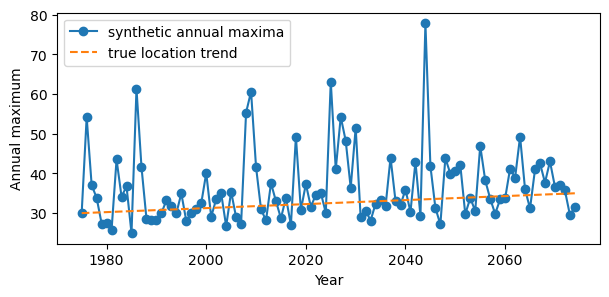

In [71]:
# Synthetic annual maxima from nsEVDx's own nonstationary sampler.
np.random.seed(42)
n_years = 100
years = np.arange(1975, 1975 + n_years)
time = np.linspace(0.0, 1.0, n_years)
cov = time[None, :]
config = [1, 0, 0]
true_params = [30, 5, 5, -0.3]  # [B0, B1, sigma, xi]
data = ns.NonStationaryEVD.ns_EVDrvs(
    genextreme, true_params, cov, config, size=n_years
)
true_mu = true_params[0] + true_params[1] * time

plt.figure(figsize=(7, 3))
plt.plot(years, data, 'o-', label='synthetic annual maxima')
plt.plot(years, true_mu, '--', label='true location trend')
plt.xlabel('Year')
plt.ylabel('Annual maximum')
plt.legend()
plt.show()


## Fit the nonstationary GEV model

The configuration `[1, 0, 0]` means that only the location parameter changes with time: `mu_t = B0 + B1*time_t`. The scale `sigma` and shape `xi` are stationary. For this configuration the parameter order is `[B0, B1, sigma, xi]`.


In [72]:
config = [1, 0, 0]
shape, loc, scale = ns.EVD_parsViaMLE(data, genextreme)
initial_params = [loc, 0.0, scale, shape]

model = ns.NonStationaryEVD(config, data, cov, genextreme)
result = model.MH_Hmc(
    num_samples=2000,
    initial_params=initial_params,
    burn_in=1000,
    num_chains=4,
    n_jobs=4,
    show_progress=False,
)


MCMC CONVERGENCE REPORT
-------------------------------------------------------
Average Acceptance: 72.01%
Convergence Check: PASSED (r_hat < 1.1)

B0 (location intercept)        R-hat: 1.0006
B1 (location slope for covariate 1) R-hat: 1.0003
sigma (scale)                  R-hat: 1.0068
xi (shape)                     R-hat: 1.0183


In [73]:

sample_all_chains = np.vstack(result['chains'])
posterior_draws = sample_all_chains[::10]
params = np.mean(sample_all_chains, axis=0)
print('posterior draws:', sample_all_chains.shape)
print('posterior mean:', params)


posterior draws: (8000, 4)
posterior mean: [29.561959  4.761494  4.823597 -0.320643]


## Risk and return-period results

`design_level` is the fixed value whose exceedance is evaluated. Risk is the probability of at least one exceedance during the design life, while the Salas & Obeysekera return period is the expected waiting time to the first exceedance. Posterior draws provide uncertainty intervals for these quantities.


In [74]:
design_level = float(np.quantile(data, 0.97))
horizon = n_years

risk = model.nonstationary_risk(
    design_level, horizon, params=params, covariates=cov,
    posterior_samples=posterior_draws,
)
reliability = model.nonstationary_reliability(
    design_level, horizon, params=params, covariates=cov,
    posterior_samples=posterior_draws,
)
pmf = model.first_exceedance_pmf(
    design_level, horizon, params=params, covariates=cov,
    posterior_samples=posterior_draws,
)
return_period = model.nonstationary_return_period(
    design_level, horizon=horizon, params=params, covariates=cov,
    posterior_samples=posterior_draws,
)

print(f'design level: {design_level:.2f}')
print(f'risk: {risk["risk"]:.3f}')
print(f'90% risk interval: '
      f'{risk["uncertainty"]["risk"]["lower"]:.3f} - '
      f'{risk["uncertainty"]["risk"]["upper"]:.3f}')
print(f'reliability: {reliability["reliability"]:.3f}')
print(f'expected first exceedance: {return_period["return_period"]:.2f} years')
print(f'90% return-period interval: '
      f'{return_period["uncertainty"]["return_period"]["lower"]:.2f} - '
      f'{return_period["uncertainty"]["return_period"]["upper"]:.2f} years')


design level: 60.65
risk: 0.973
90% risk interval: 0.812 - 0.999
reliability: 0.027
expected first exceedance: 29.89 years
90% return-period interval: 16.70 - 52.47 years


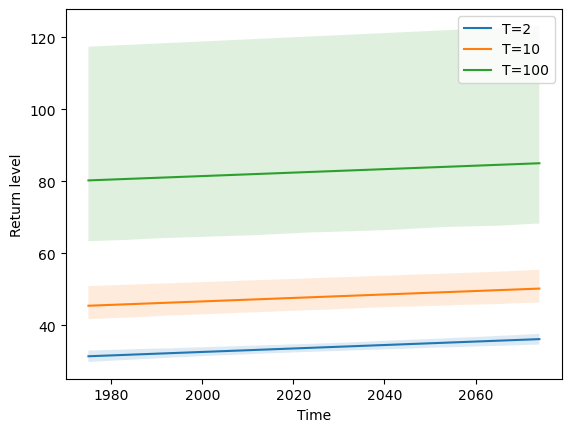

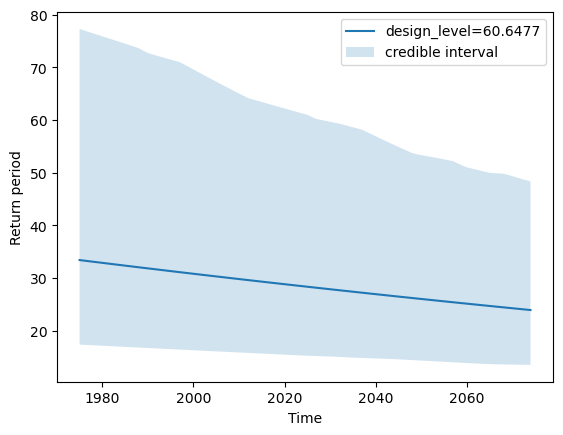

In [75]:
model.plot_return_levels(
    return_periods=(2,  10, 100),
    params=params,
    covariates=cov,
    time=years,
    posterior_samples=posterior_draws,
)
plt.show()

model.plot_return_periods(
    design_level=design_level,
    params=params,
    covariates=cov,
    time=years,
    posterior_samples=posterior_draws,
)
plt.show()
